# 03 · Segmentation: the graph, the attributes, and the benchmark with no model

Banks segment merchants by what they know about them: MCC, size, ticket, channel, card mix.
Feature 4 asked whether segmenting them by **who buys from them** works better for pricing.
This notebook answers that, and puts the answer on a ladder so the numbers mean something:

| Rung | Method | Idea |
|---|---|---|
| Benchmark | **mcc_group** | Leave every merchant in its own category. No model at all. |
| Unsupervised | **baseline** · **graph** · **hybrid** · **leiden** | Group merchants that look alike, by attributes, by the graph, by both, or by communities. |
| Supervised | **supervised** · **supervised_graph** | Split merchants by the number the pricing decision turns on. |

The business metric is the same for all of them: predict the **relative burden** (MDR over the
merchant's margin) of merchants held out of the fit. The spec calls relative burden the best
predictor of dropping acceptance, and Feature 5 will replace it with the churn curve itself.

> **Synthetic data.** The generator planted the clienteles the graph is trying to recover, so
> this shows whether the method finds structure that exists, not how Colombian merchants
> behave. Run `python -m ips.tasks generate` and `python -m ips.tasks dbt` first.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

from ips.graph.baseline_kmeans import BENCHMARK, feature_matrix
from ips.graph.clustering import cluster_merchants, combine_spaces
from ips.graph.evaluate import marginal_verdict, out_of_sample
from ips.graph.pipeline import (
    BASELINE,
    GRAPH,
    HYBRID,
    LEIDEN,
    SUPERVISED,
    SUPERVISED_GRAPH,
    run_segmentation,
)
from ips.graph.supervised import fit_supervised
from ips.utils.config import load_config

pl.Config.set_thousands_separator(",")
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(190)
pl.Config.set_tbl_cols(14)
pl.Config.set_fmt_str_lengths(90)
start = time.perf_counter()
cfg = load_config()

Chart style: the dataviz reference palette, as in notebooks 01 and 02. Categorical
colours in a fixed order, one blue ramp for magnitude, and the accent reserved for whichever
method wins the rung being shown.

In [2]:
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": AXIS,
        "ytick.color": AXIS,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)
METHOD_LABEL = {
    BENCHMARK: "MCC group (no model)",
    BASELINE: "k-means, attributes",
    GRAPH: "k-means, graph",
    HYBRID: "k-means, attributes + graph",
    LEIDEN: "Leiden communities",
    SUPERVISED: "Supervised, attributes",
    SUPERVISED_GRAPH: "Supervised, attributes + graph",
}


def compact(value, _pos=None):
    """Three significant digits: 1,234 -> 1.23k; 5,600,000 -> 5.60M."""
    for threshold, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= threshold:
            return f"{value / threshold:#.3g}".rstrip(".") + suffix
    return f"{value:,.0f}"


def pretty(name):
    return str(name).replace("_", " ").capitalize()


def emphasis(values, best="max"):
    """Accent for the winner, neutral for the rest: the chart should say who won."""
    target = max(values) if best == "max" else min(values)
    return [SERIES[0] if value == target else AXIS for value in values]

In [3]:
run = run_segmentation(cfg)
comparison = run.comparison
population = run.population
stats = run.graph_stats
print(
    f"{stats['merchants']:,.0f} merchants and {stats['cardholders']:,.0f} cards in the window "
    f"({cfg.segmentation.window_months} months) | {stats['edges']:,.0f} edges | "
    f"{population.height:,} merchants segmented (>= {cfg.segmentation.min_purchases} purchases)"
)

09:30:32 INFO ips.graph.pipeline: 5,801,142 edges, 30,521 merchants with purchases


09:31:35 INFO ips.graph.pipeline: segmented 28,438 merchants in 64.3 s


30,521 merchants and 149,913 cards in the window (24 months) | 4,261,867 edges | 28,438 merchants segmented (>= 10 purchases)


## 1. The graph the segmentation learns from

Every edge is a card that bought from a merchant in the window, weighted by purchases. The
degree distribution is long-tailed: most merchants serve a handful of cards and a few serve
thousands, which is why a merchant needs a minimum of purchases before it gets a segment.

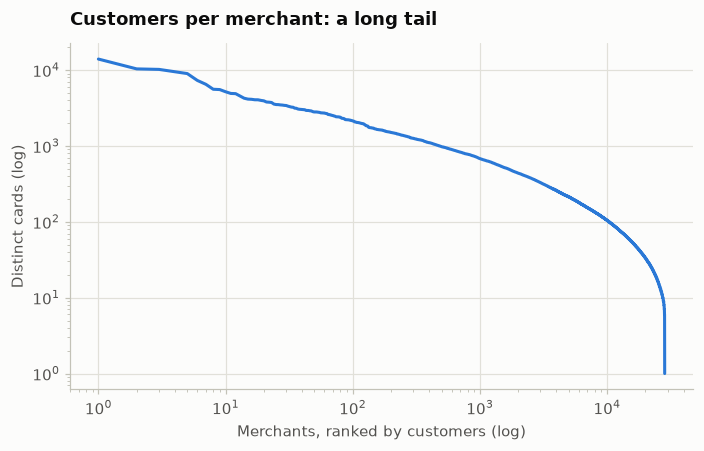

metric,value
str,str
"""cardholders""","""1.499e+05"""
"""merchants""","""3.052e+04"""
"""edges""","""4.262e+06"""
"""purchases""","""5.984e+06"""
"""density""","""0.0009315"""
"""mean_merchants_per_cardholder""","""28.43"""
"""median_customers_per_merchant""","""57"""


In [4]:
customers = np.sort(population["n_customers"].to_numpy())[::-1]
ranked = np.arange(1, len(customers) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(ranked, customers, color=SERIES[0])
ax.set_xlabel("Merchants, ranked by customers (log)")
ax.set_ylabel("Distinct cards (log)")
ax.set_title("Customers per merchant: a long tail")
fig.tight_layout()
plt.show()
pl.DataFrame({"metric": list(stats), "value": [f"{value:,.4g}" for value in stats.values()]})

## 2. The ladder

One row per method. `burden_r2_oos` is the business metric: how well a segment's average
predicts the relative burden of merchants held out of the fit. `eta2_*` is in-sample
homogeneity, which always improves with more segments, so it is read next to the out-of-sample
column. `nmi_mcc_group` says how much a segmentation is the MCC group relabelled, and
`nmi_clientele` compares it with the clientele the generator planted — a diagnostic, never the
criterion.

In [5]:
comparison.with_columns(
    pl.col("method").replace_strict(METHOD_LABEL).alias("method"), cs.float().round(3)
)

method,segments,coverage,largest_segment_share,eta2_interchange,eta2_burden,burden_r2_oos,burden_mae_ratio,burden_top_decile_lift,silhouette,nmi_mcc_group,nmi_clientele
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MCC group (no model)""",12.0,1.0,0.261,0.736,0.744,0.74,0.437,3.625,NaN,1.0,0.033
"""k-means, attributes""",10.0,1.0,0.237,0.492,0.086,0.081,0.952,1.546,0.185,0.213,0.059
"""k-means, graph""",12.0,1.0,0.119,0.403,0.015,0.011,0.991,1.068,0.184,0.035,0.373
"""k-means, attributes + graph""",12.0,1.0,0.177,0.657,0.074,0.069,0.965,1.523,0.086,0.2,0.22
"""Leiden communities""",8.0,0.549,0.351,0.045,0.002,0.001,1.0,0.834,NaN,0.008,0.002
"""Supervised, attributes""",12.0,1.0,0.401,0.88,0.755,0.751,0.432,3.807,NaN,0.838,0.033
"""Supervised, attributes + graph""",12.0,1.0,0.401,0.88,0.755,0.751,0.432,3.807,NaN,0.838,0.033


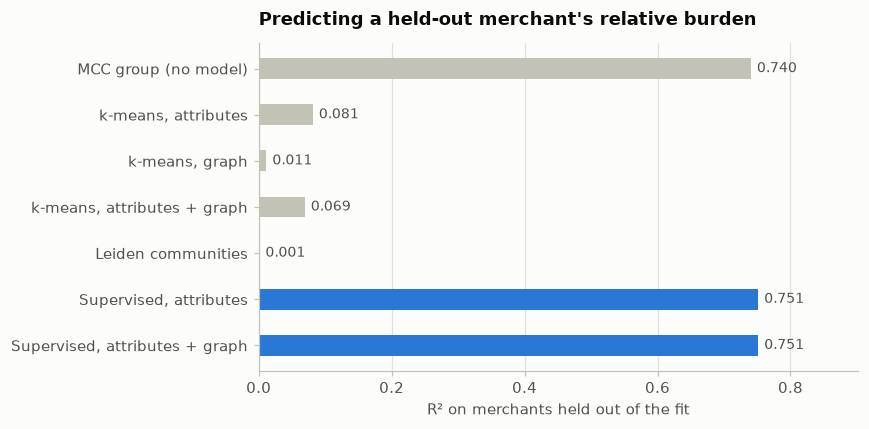

The graph segmentation does not beat the baseline on out-of-sample relative burden: R² 0.011 vs 0.081 (-0.070).
The supervised segmentation beats the mcc_group on out-of-sample relative burden: R² 0.751 vs 0.740 (+0.011).
With the same predictor, the graph adds nothing measurable on top of the attributes: R² 0.751 vs 0.751.


In [6]:
metric = "burden_r2_oos"
scores = comparison.select("method", metric)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    [METHOD_LABEL[m] for m in scores["method"]],
    scores[metric],
    height=0.45,
    color=emphasis(scores[metric].to_list()),
)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in scores[metric]], padding=4, color=INK_2, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, max(scores[metric].max() * 1.2, 0.05))
ax.grid(axis="y", visible=False)
ax.set_xlabel("R² on merchants held out of the fit")
ax.set_title("Predicting a held-out merchant's relative burden")
fig.tight_layout()
plt.show()
for sentence in run.verdicts():
    print(sentence)

Three readings, and none of them favours the graph:

- **The benchmark that needs no model beats every unsupervised method.** Keeping merchants in
  their own MCC group predicts held-out burden far better than k-means on attributes does.
  k-means compresses twelve categories into eight clusters and loses the very thing that drives
  the target.
- **The supervised segmentation is the one worth shipping.** Splitting merchants by the number
  the decision turns on reaches the benchmark's level while using a handful of readable rules.
- **The graph adds nothing on this target**, alone or on top of the attributes. The next
  section shows that is not an artefact of the clustering step.

### Is the verdict about the number of segments?

Each method picked its own number of segments. Sweeping it for every representation answers
the obvious objection: the graph is behind at **every** size, and the supervised tree is ahead
at every size.

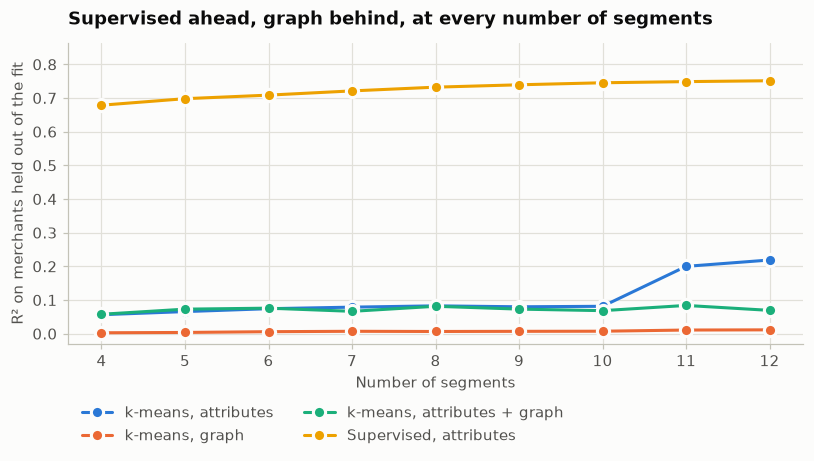

k,baseline,graph,hybrid,supervised
i64,f64,f64,f64,f64
4,0.056,0.003,0.058,0.679
5,0.066,0.004,0.073,0.698
6,0.074,0.006,0.076,0.709
7,0.079,0.007,0.066,0.721
8,0.083,0.007,0.081,0.732
9,0.08,0.007,0.073,0.739
10,0.081,0.007,0.068,0.745
11,0.2,0.011,0.084,0.749
12,0.219,0.011,0.069,0.751


In [7]:
position = {int(m): i for i, m in enumerate(run.embedding.merchant_ids)}
rows = np.array([position[int(m)] for m in population["merchant_id"]])
vectors = run.embedding.vectors[rows]
tabular, names = feature_matrix(population, cfg)
both = combine_spaces(tabular, vectors)
burden = population["relative_burden"].to_numpy()
ids = population["merchant_id"].to_numpy()
unsupervised = {BASELINE: tabular, GRAPH: vectors, HYBRID: both}


def sweep_row(method, k):
    if method == SUPERVISED:
        labels = fit_supervised(population, tabular, cfg, SUPERVISED, leaves=k)[0].labels
    else:
        labels = cluster_merchants(method, ids, unsupervised[method], cfg, k=k).labels
    return out_of_sample(burden, labels["segment"].to_numpy(), cfg)["burden_r2_oos"]


sweep = pl.DataFrame(
    [
        {"method": method, "k": k, "burden_r2_oos": sweep_row(method, k)}
        for method in (BASELINE, GRAPH, HYBRID, SUPERVISED)
        for k in cfg.segmentation.k_values
    ]
)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for i, method in enumerate((BASELINE, GRAPH, HYBRID, SUPERVISED)):
    line = sweep.filter(pl.col("method") == method).sort("k")
    ax.plot(
        line["k"],
        line["burden_r2_oos"],
        color=SERIES[i],
        marker="o",
        markersize=8,
        markeredgecolor=SURFACE,
        markeredgewidth=2,
        label=METHOD_LABEL[method],
    )
ax.set_xticks(list(cfg.segmentation.k_values))
ax.set_xlabel("Number of segments")
ax.set_ylabel("R² on merchants held out of the fit")
ax.set_ylim(-0.03, max(sweep["burden_r2_oos"].max() * 1.15, 0.05))
ax.set_title("Supervised ahead, graph behind, at every number of segments")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.16), ncol=2)
fig.tight_layout()
plt.show()
sweep.pivot(on="method", index="k", values="burden_r2_oos").sort("k").with_columns(
    cs.float().round(3)
)

## 3. What the graph adds, with the clustering step removed

The comparison above judges representations through a segmentation. This one does not: it
fits the same predictor on each representation and asks whether the embeddings carry anything
about relative burden that the attributes do not already have.

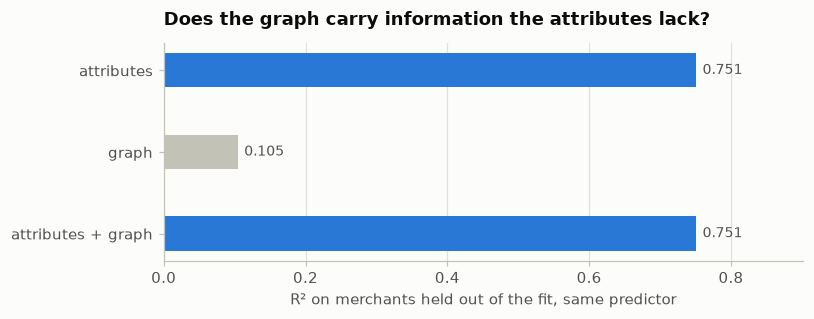

With the same predictor, the graph adds nothing measurable on top of the attributes: R² 0.751 vs 0.751.


space,r2_oos,gap
str,f64,f64
"""attributes""",0.751,0.0
"""graph""",0.105,-0.646
"""attributes + graph""",0.751,0.0


In [8]:
marginal = run.marginal
fig, ax = plt.subplots(figsize=(7.5, 3))
bars = ax.barh(
    marginal["space"].to_list(),
    marginal["r2_oos"],
    height=0.42,
    color=emphasis(marginal["r2_oos"].to_list()),
)
ax.bar_label(
    bars, labels=[f"{v:.3f}" for v in marginal["r2_oos"]], padding=4, color=INK_2, fontsize=9
)
ax.invert_yaxis()
ax.set_xlim(0, max(marginal["r2_oos"].max() * 1.2, 0.05))
ax.grid(axis="y", visible=False)
ax.set_xlabel("R² on merchants held out of the fit, same predictor")
ax.set_title("Does the graph carry information the attributes lack?")
fig.tight_layout()
plt.show()
print(marginal_verdict(marginal))
marginal.with_columns(cs.float().round(3))

## 4. Homogeneity: how much variation each segmentation explains in sample

Effective interchange is weighted by volume, because that is where the network's revenue sits;
relative burden is per merchant, because dropping acceptance is a per-merchant decision. These
are in-sample numbers: more segments always help, which is why the ladder is decided
out of sample.

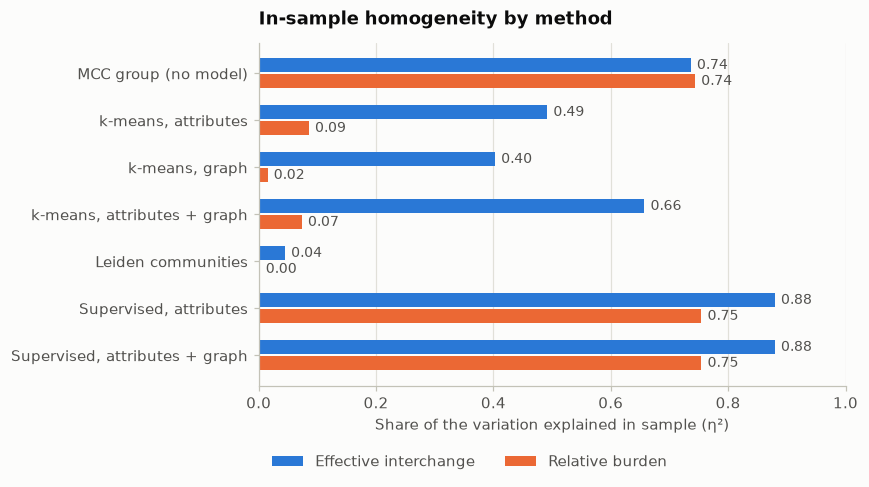

In [9]:
metrics = [("eta2_interchange", "Effective interchange"), ("eta2_burden", "Relative burden")]
methods = comparison["method"].to_list()
positions = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(8, 4.6))
for i, (column, label) in enumerate(metrics):
    bars = ax.barh(
        positions + (i - 0.5) * 0.34, comparison[column], height=0.3, color=SERIES[i], label=label
    )
    ax.bar_label(
        bars,
        labels=[f"{v:.2f}" for v in comparison[column]],
        padding=4,
        color=INK_2,
        fontsize=9,
    )
ax.set_yticks(positions, [METHOD_LABEL[m] for m in methods])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of the variation explained in sample (η²)")
ax.set_title("In-sample homogeneity by method")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.16), ncol=2)
fig.tight_layout()
plt.show()

## 5. What the segments are made of

Each cell is the share of a segment's volume that comes from one MCC group. The attribute
baseline mixes categories inside its clusters; the graph cuts across them, grouping merchants
that share customers whatever they sell.

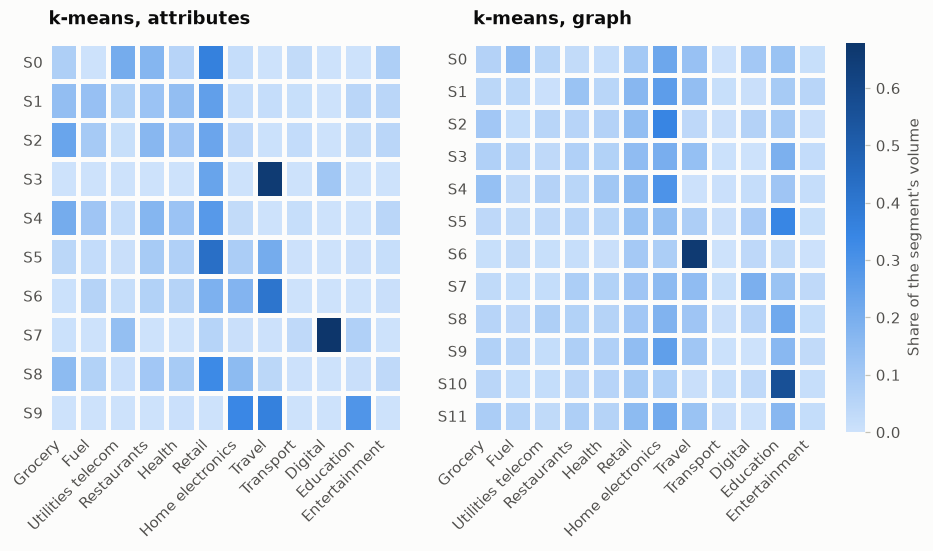

In [10]:
def mix(method):
    labels = run.method(method).labels
    joined = population.join(labels, on="merchant_id").filter(pl.col("segment") >= 0)
    share = (
        joined.group_by("segment", pl.col("mcc_group").cast(pl.Utf8))
        .agg(pl.col("gdv_cop").sum())
        .with_columns((pl.col("gdv_cop") / pl.col("gdv_cop").sum().over("segment")).alias("share"))
    )
    groups = list(cfg.group_names)
    segments = sorted(share["segment"].unique().to_list())
    matrix = np.zeros((len(segments), len(groups)))
    for row, group, value in share.select("segment", "mcc_group", "share").iter_rows():
        matrix[segments.index(row), groups.index(group)] = value
    return matrix, segments, groups


blues = LinearSegmentedColormap.from_list("blues", BLUES)
panels = {method: mix(method) for method in (BASELINE, GRAPH)}
top = max(matrix.max() for matrix, _, _ in panels.values())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), width_ratios=[1, 1])
for ax, method in zip(axes, panels, strict=True):
    matrix, segments, groups = panels[method]
    mesh = ax.pcolormesh(matrix, cmap=blues, edgecolors=SURFACE, linewidth=2, vmin=0, vmax=top)
    ax.set_xticks(
        np.arange(len(groups)) + 0.5, [pretty(g) for g in groups], rotation=45, ha="right"
    )
    ax.set_yticks(np.arange(len(segments)) + 0.5, [f"S{s}" for s in segments])
    ax.invert_yaxis()
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(METHOD_LABEL[method])
bar = fig.colorbar(mesh, ax=axes, pad=0.02)
bar.outline.set_visible(False)
bar.set_label("Share of the segment's volume", color=INK_2)
plt.show()

## 6. The segmentation a pricing team would ship

The supervised segments come with the rule that defines them, which is what makes them usable
in a memo: each row below is a group of merchants and the condition that puts a merchant in
it. `predicted` is the burden the tree expects for that segment.

In [11]:
run.rules.with_columns(cs.float().round(3))

segment,merchants_in_fit,predicted,rule
i64,i64,f64,str
0,"4,313",0.554,"""mcc_group = grocery"""
1,640,0.528,"""mcc_group ≠ grocery and mcc_group ≠ travel and mcc_group = fuel"""
2,"1,342",0.279,"""mcc_group ≠ grocery and mcc_group ≠ travel and mcc_group ≠ fuel and log_avg_ticket > -0.31…"
3,"1,095",0.275,"""mcc_group ≠ grocery and mcc_group ≠ travel and mcc_group ≠ fuel and log_avg_ticket > -0.31…"
4,584,0.464,"""mcc_group ≠ grocery and mcc_group = travel and cross_border_share <= 1.32"""
5,133,0.732,"""mcc_group ≠ grocery and mcc_group = travel and cross_border_share > 1.32"""
6,596,0.092,"""mcc_group ≠ grocery and mcc_group ≠ travel and mcc_group ≠ fuel and log_avg_ticket > -0.31…"
7,"2,076",0.287,"""mcc_group ≠ grocery and mcc_group ≠ travel and mcc_group ≠ fuel and log_avg_ticket <= -0.3…"
8,183,0.131,"""mcc_group ≠ grocery and mcc_group ≠ travel and mcc_group ≠ fuel and log_avg_ticket <= -0.3…"


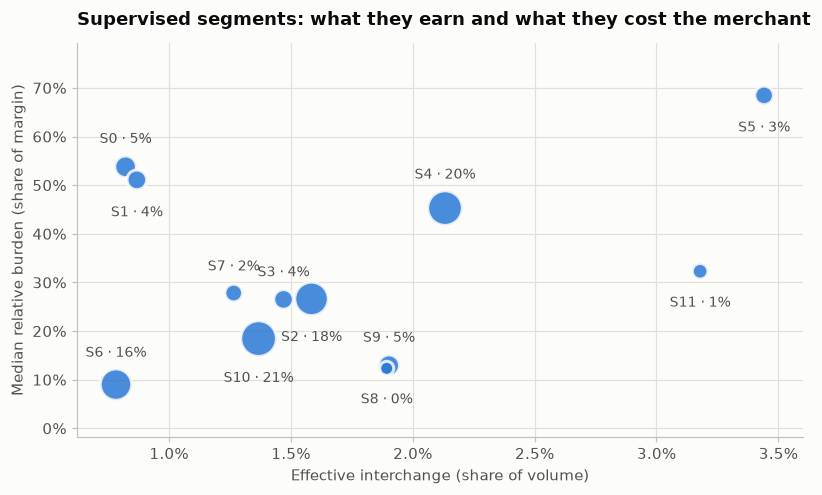

segment,merchants,volume_share,avg_ticket_cop,effective_interchange_rate,effective_mdr_rate,median_relative_burden,p90_relative_burden,cnp_share,cross_border_share,top_mcc_group,top_city,top_size_tier
i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
10,"11,406",0.2122,"128,812.6593",0.0137,0.0195,0.1845,0.2561,0.2025,0.0,"""retail, health, utilities_telecom""","""other, bogota, medellin""","""small, medium, micro"""
4,873,0.1976,"1,052,077.2301",0.0213,0.0264,0.4529,0.6188,0.6437,0.0,"""travel""","""other, bogota""","""small, medium, micro"""
2,"1,884",0.1823,"830,055.5175",0.0158,0.0208,0.2662,0.3665,0.2724,0.0,"""home_electronics""","""other, bogota, medellin""","""small, medium, micro"""
6,846,0.1564,"1,083,990.0636",0.0078,0.0126,0.0899,0.1222,0.3159,0.0,"""education""","""other, bogota, medellin""","""medium, small, large"""
0,"6,210",0.0548,"44,195.572",0.0082,0.0158,0.5378,0.7459,0.0565,0.0,"""grocery""","""other, bogota, medellin""","""medium, small, micro"""
9,"1,237",0.051,"138,332.7142",0.019,0.0249,0.1292,0.1988,1.0,0.0983,"""digital""","""""","""medium, small, micro"""
1,903,0.0387,"77,084.7134",0.0087,0.0151,0.511,0.7309,0.0,0.0,"""fuel""","""other, bogota, medellin""","""small, medium, large"""
3,"1,562",0.0381,"85,084.1934",0.0147,0.0211,0.2651,0.3695,0.0904,0.0,"""restaurants""","""other, bogota, medellin""","""small, medium, micro"""
5,179,0.0311,"1,314,372.081",0.0344,0.042,0.6847,0.9876,0.8253,1.0,"""travel""","""""","""medium, small, micro"""


In [12]:
profiles = run.profiles
fig, ax = plt.subplots(figsize=(7.5, 4.6))
sizes = profiles["volume_share"].to_numpy()
ax.scatter(
    profiles["effective_interchange_rate"],
    profiles["median_relative_burden"],
    s=80 + 2200 * sizes,
    color=SERIES[0],
    alpha=0.85,
    edgecolors=SURFACE,
    linewidths=2,
    zorder=3,
)
labelled = profiles.select(
    "segment", "effective_interchange_rate", "median_relative_burden", "volume_share"
).sort("median_relative_burden")
for index, (segment, interchange, burden_value, share) in enumerate(labelled.iter_rows()):
    above = index % 2 == 0
    offset = 12 + 26 * share
    ax.annotate(
        f"S{segment} · {share:.0%}",
        xy=(interchange, burden_value),
        xytext=(0, offset if above else -offset - 4),
        textcoords="offset points",
        ha="center",
        va="bottom" if above else "top",
        color=INK_2,
        fontsize=9,
    )
ax.margins(x=0.06, y=0.18)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Effective interchange (share of volume)")
ax.set_ylabel("Median relative burden (share of margin)")
ax.set_title("Supervised segments: what they earn and what they cost the merchant")
fig.tight_layout()
plt.show()
profiles.with_columns(cs.float().round(4))

## 7. Diagnostic: is this just the MCC, or the planted clientele?

`nmi_mcc_group` measures how much each segmentation repeats the merchant category;
`nmi_clientele` compares it with the latent clientele the generator planted. The graph is the
only method that recovers the clientele — it finds the structure it was meant to find. That
structure simply does not drive what a merchant pays.

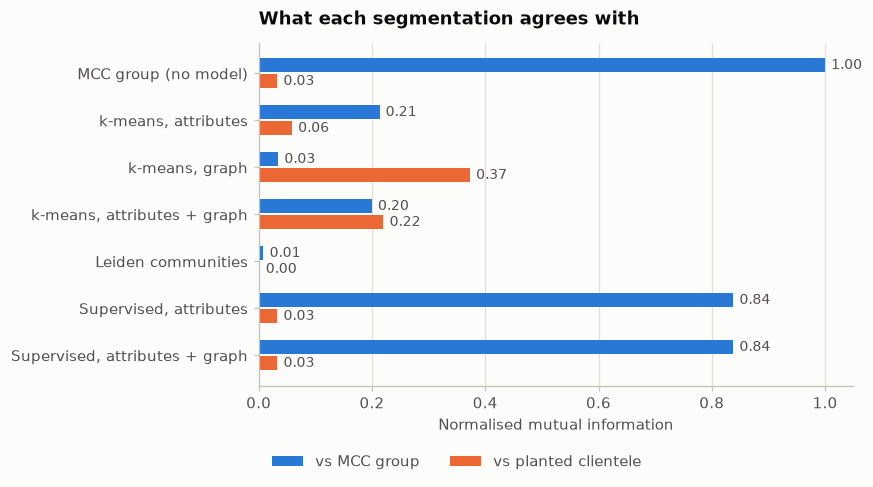

In [13]:
diagnostics = [("nmi_mcc_group", "vs MCC group"), ("nmi_clientele", "vs planted clientele")]
positions = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(8, 4.6))
for i, (column, label) in enumerate(diagnostics):
    bars = ax.barh(
        positions + (i - 0.5) * 0.34, comparison[column], height=0.3, color=SERIES[i], label=label
    )
    ax.bar_label(
        bars,
        labels=[f"{v:.2f}" for v in comparison[column]],
        padding=4,
        color=INK_2,
        fontsize=9,
    )
ax.set_yticks(positions, [METHOD_LABEL[m] for m in methods])
ax.invert_yaxis()
ax.set_xlim(0, max(1.05, comparison["nmi_clientele"].max() * 1.3))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Normalised mutual information")
ax.set_title("What each segmentation agrees with")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.16), ncol=2)
fig.tight_layout()
plt.show()

## Limits

- **The clienteles were planted.** The generator built the structure the graph looks for, so
  recovering it proves the method works on this data, not that real merchants cluster this way.
- **Relative burden is a stand-in for churn.** Feature 5 brings the acceptance curve; the same
  ladder will then carry the real churn metric, and the graph deserves a second hearing there:
  who buys where is exactly what decides *where the volume goes* when a merchant stops
  accepting.
- **Supervised segments serve the target they were cut for.** They are the right tool for
  pricing this number and the wrong one for questions about substitution.
- **Embeddings are spectral, not node2vec.** PPMI plus truncated SVD is the matrix
  factorisation that random-walk embeddings approximate (Qiu et al., 2018), chosen because it
  is deterministic and reproducible in seconds.
- **In-sample homogeneity rewards more segments**, and Leiden picks its own number of
  communities, so η² is never read on its own.

In [14]:
print(f"Notebook runtime: {time.perf_counter() - start:.1f} s")

Notebook runtime: 95.6 s
